In [7]:
from tensorflow.keras.utils import set_random_seed
from skimage import img_as_ubyte
import os
import re

import pandas as pd
import sys
from pathlib import Path
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.ticker import MultipleLocator

sys.path.append('/home/jovyan/projects/onunet')
from model import *
from data import *

sys.path.append('/home/jovyan/projects/cellcount')
from utils import *


In [8]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
set_random_seed(812)

Define paths:

In [15]:
print(os.getcwd())
os.chdir('/home/jovyan/projects/onunet')
print(os.getcwd())
#dataset = "membrane"
dataset = "optical_nerve"
path2data = os.path.join("/home/jovyan/kDrive/cellcount/data/onunet", dataset)
#path2data = "/home/jovyan/kDrive/cellcount/data/onunet/membrane"
path2train = os.path.join(path2data, "train")
print(path2train)
path2validation = os.path.join(path2data, "validation")
print(path2validation)
path2test = os.path.join(path2data, "test")
print(path2test)
path2checkpoints = "/home/jovyan/kDrive/cellcount/data/onunet/model_weights/06_09_2024_bis"
print(path2checkpoints)

/home/jovyan/projects/onunet
/home/jovyan/projects/onunet
/home/jovyan/kDrive/cellcount/data/onunet/optical_nerve/train
/home/jovyan/kDrive/cellcount/data/onunet/optical_nerve/validation
/home/jovyan/kDrive/cellcount/data/onunet/optical_nerve/test
/home/jovyan/kDrive/cellcount/data/onunet/model_weights/06_09_2024_bis


## Plot accuracy and loss plots :

In [16]:
history_filename = 'optical_nerve_training_history'
path2history = os.path.join(path2checkpoints, history_filename + '.csv')
history = pd.read_csv(path2history)

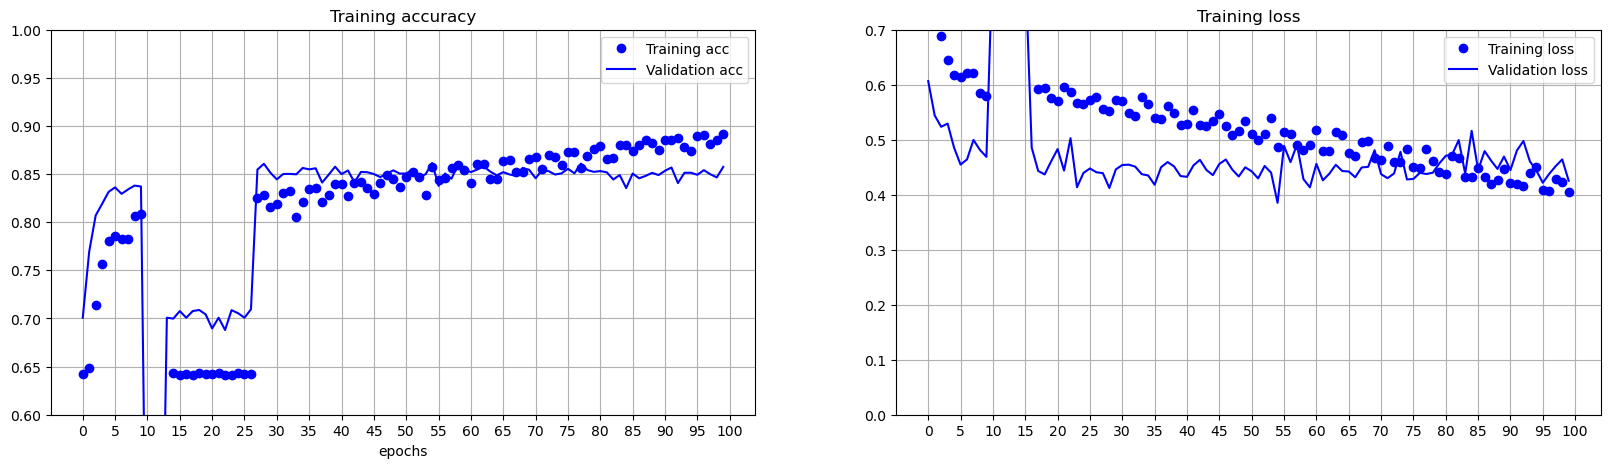

In [17]:
acc = list(history.binary_accuracy)
val_acc = list(history.val_binary_accuracy)
loss = list(history.loss)
val_loss = list(history.val_loss)
epochs = list(history.epoch)

fig = plt.figure(figsize=(20, 5))

ax = plt.subplot(1,2,1)
ax.plot(epochs, acc, 'bo', label='Training acc')
ax.plot(epochs, val_acc, 'b', label='Validation acc')
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_major_locator(MultipleLocator(0.05))
ax.set_ylim(ymin=0.6, ymax=1)
ax.set_xlabel('epochs')
ax.set_title('Training accuracy')
ax.legend()
ax.grid()

ax = plt.subplot(1,2,2)
ax.plot(epochs, loss, 'bo', label='Training loss')
ax.plot(epochs, val_loss, 'b', label='Validation loss')
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.set_ylim(ymin=0, ymax=0.7)
ax.set_title('Training loss')
ax.legend()
ax.grid()

plt.show()
fig.savefig(os.path.join(path2checkpoints, history_filename + '.png'), facecolor='white')

## Making a prediction on the test data:

In [4]:
if dataset == "optical_nerve": # For optical nerve data:
    num_image = 4
    def testGenerator(
        test_path,
        num_image,
        target_size = (512, 512),
        flag_multi_class = False,
        as_gray = True):

        basepath = Path(test_path)
        tiles = (entry for entry in basepath.iterdir() if entry.is_file() and entry.name.startswith('tile') and entry.name.endswith('.png')) # generator
        tiles_names = sorted([entry.name for entry in tiles])
        for tile in tiles_names:
            img = io.imread(os.path.join(test_path, tile), as_gray = as_gray)
            img = img / 255.
            img = trans.resize(img, target_size)
            img = np.reshape(img, img.shape + (1,)) if (not flag_multi_class) else img
            img = np.reshape(img, (1,) + img.shape)
            yield img

    def tile_coordinates(path2directory):
        basepath = Path(path2directory)
        tiles = (entry for entry in basepath.iterdir() if entry.is_file() and entry.name.startswith('tile') and entry.name.endswith('.png')) # generator
        tiles_names = sorted([entry.name for entry in tiles])
        tile_coords = []
        for tile in tiles_names:  
            tile_name_splitted = re.split('_|\.', tile)
            i = tile_name_splitted[2]
            j = tile_name_splitted[3]
            tile_coords.append((int(i),int(j)))
        
        return tile_coords

elif dataset == "membrane":
    num_image = 30
    ## original from unet-master :
    def testGenerator(test_path,num_image = 30,target_size = (256,256),flag_multi_class = False,as_gray = True):
        for i in range(num_image):
            img = io.imread(os.path.join(test_path,"%d.png"%i),as_gray = as_gray)
            img = img / 255.
            img = trans.resize(img,target_size)
            img = np.reshape(img,img.shape+(1,)) if (not flag_multi_class) else img
            img = np.reshape(img,(1,)+img.shape)
            yield img

    # def saveResult(save_path, npyfile, flag_multi_class = False, num_class = 2):
    #     for i, item in enumerate(npyfile):
    #         #img = labelVisualize(num_class,COLOR_DICT,item) if flag_multi_class else item[:,:,0]
    #         img = item[:,:,0]
    #         #io.imsave(os.path.join(save_path,"%d_predict.png"%i),img)
    #         io.imsave(os.path.join(save_path, "%d_predict.png"%i), img_as_ubyte(img)) # new

else:
    raise ValueError("Unknown dataset !")

In [5]:
def saveResult(save_path, npyfile, tile_coordinates=None):
    for i, item in enumerate(npyfile):
        img = item[:,:,0]
        print(np.max(img))
        if tile_coordinates is not None:
            filename = f"predict_{tile_coordinates[i][0]}_{tile_coordinates[i][1]}.png"
        else: # string formatting for membrane dataset
            filename = f"{i}_predict.png"
        io.imsave(os.path.join(save_path, filename), img_as_ubyte(img))

In [11]:
#test_generator = testGenerator(path2test, num_image=num_image, target_size = (512, 512))
#test_generator
#tile_coords = tile_coordinates(path2test)

In [6]:
path2checkpoints

'/home/jovyan/kDrive/cellcount/data/onunet/model_weights/28_02_2024'

In [7]:
test_generator = testGenerator(path2test, num_image=num_image, target_size = (512, 512))
if dataset == 'optical_nerve':
    tile_coords = tile_coordinates(path2test)
else:
    tile_coords = None
print(tile_coords)
model = weighted_loss_unet(input_shape=(512, 512, 1), inference=True)
#model = unet()
#model = unet_minimal()
model.load_weights(os.path.join(path2checkpoints, "optical_nerve_weights.hdf5"))
results = model.predict(test_generator, verbose=1)
saveResult(path2test, results, tile_coords)


[(5, 4), (6, 2), (7, 11), (8, 3)]
4/4 [==============================] - 5s 1s/step
0.8568038
0.8568038
0.8568038
0.8568038


### Various tests

In [11]:
test_generator = testGenerator(path2test, num_image=num_image, target_size = (512, 512))
test_image_list = list(test_generator)

In [26]:
# histogram of grays of a test image:
# test_generator = testGenerator(path2test, target_size = (512, 512))
# num_batch = 0
# for i, batch in enumerate(test_generator):
#     images_batch = batch[0]
#     if i >= num_batch:
#         print('images batch shape :', images_batch.shape)
#         n, bins, patches = plt.hist(images_batch.flatten(), 50, density=True, facecolor='g', alpha=0.75)
#         break

In [12]:
i = 3
thr = 0.5
test_image = test_image_list[i][0]
raw_mask = results[i]
binary_mask = np.zeros(raw_mask.shape)
binary_mask[raw_mask > thr] = 1
binary_mask[raw_mask <= thr] = 0

IndexError: list index out of range

In [12]:
np.min(raw_mask)

8.855573e-12

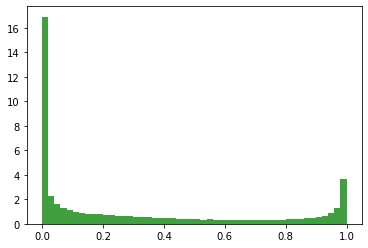

In [13]:
n, bins, patches = plt.hist(raw_mask.flatten(), 50, density=True, facecolor='g', alpha=0.75)

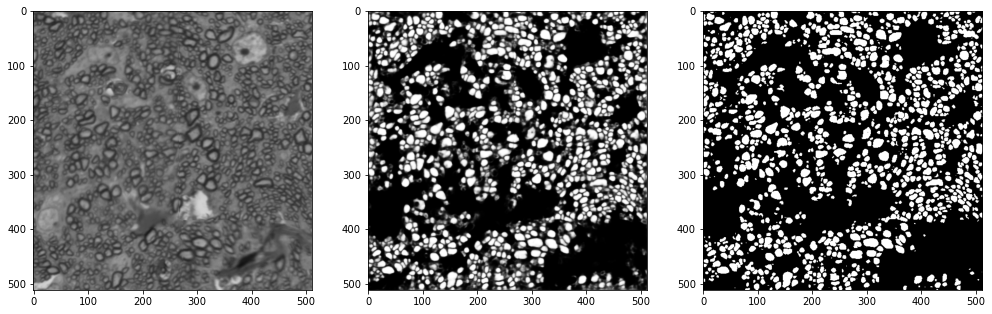

In [14]:
# create figure
fig = plt.figure(figsize=(17, 17))
fig.add_subplot(1, 3, 1)
plt.imshow(test_image, cmap='gray', vmin=0, vmax=1)
fig.add_subplot(1, 3, 2)
plt.imshow(raw_mask, cmap='gray', vmin=0, vmax=1)
fig.add_subplot(1, 3, 3)
plt.imshow(binary_mask, cmap='gray', vmin=0, vmax=1)


### Import a predicted tile:

/home/jovyan/kDrive/cellcount/data/onunet/optical_nerve/test


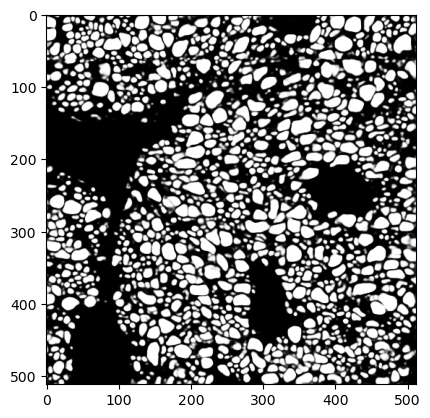

In [6]:
print(path2test)
my_pred = import_pred_asarray(path2test, i=5, j=4, show_pred=True, verbose=False)

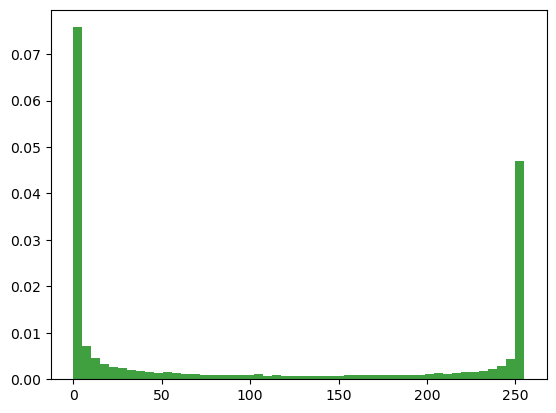

In [7]:
n, bins, patches = plt.hist(my_pred.flatten(), 50, density=True, facecolor='g', alpha=0.75)